In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import scipy
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

## load layouts from file

In [2]:
Experiment1_Layout = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250512_mACmChPOLR2A_Inhibitors_Chase/250512_mACmChPOLR2A_Inhibitors_Chase.csv")
Experiment2_Layout = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250520_mACmChPOLR2A_Inhibitors_Chase/250520_mACmChPOLR2A_Inhibitor_Chase.csv")

## for each experiment, load quantification files from relevant directories, and assemble into data frames

### experiment 1

In [3]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250512_mACmChPOLR2A_Inhibitors_Chase/20250515_191621_146/QUANTIFICATION")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

908

In [4]:
Path(quantification_files_1[100]).stem, Path(quantification_files_1[100]).stem[4:7],Path(quantification_files_1[100]).stem[39:43]

('WellC19_Channel561,405,647,488_Seq0016_0002.ome', 'C19', '0002')

In [5]:
qdfs = list()


for f in tqdm(quantification_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[39:43] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|█████████████████████████████████████████| 908/908 [00:10<00:00, 85.96it/s]


In [6]:
Intensities_Experiment1 = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "RFP_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : quantifcation_percell_1['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_1['Nuclei_area']
})

In [7]:
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250520_mACmChPOLR2A_Inhibitors_Chase/20250525_190608_221/QUANTIFICATION/")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

800

In [8]:
Path(quantification_files_2[101]).stem, Path(quantification_files_2[100]).stem[4:7],Path(quantification_files_2[100]).stem[39:43]

('WellF13_Channel561,405,647,488_Seq0050_0004.ome', 'L05', '0002')

In [9]:
qdfs2 = list()


for f in tqdm(quantification_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs2.append(data)

quantifcation_percell_2 = pd.concat(qdfs2, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[4:7] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[39:43] for f in files]
quantifcation_percell_2['fov'] = fovs

100%|█████████████████████████████████████████| 800/800 [00:08<00:00, 89.72it/s]


In [10]:
Intensities_Experiment2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "RFP_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_561'],
    "GFP_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : quantifcation_percell_2['Nuclei_intensity_mean_405'],
    "NucleusArea" : quantifcation_percell_2['Nuclei_area']
})

In [11]:
IntensitiesByWell_Experiment1 = Intensities_Experiment1.groupby('WELL').mean().reset_index().merge(Experiment1_Layout, how = 'left')
IntensitiesByWell_Experiment2 = Intensities_Experiment2.groupby('WELL').mean().reset_index().merge(Experiment2_Layout, how = 'left')

In [12]:
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250512_mACmChPOLR2A_Inhibitors_Chase'
IntensitiesByWell_Experiment2['EXPERIMENT'] = '250520_mACmChPOLR2A_Inhibitors_Chase'

In [13]:
IntensitiesByWell_Experiment1.to_csv('250512_mACmChPOLR2A_Inhibitors_Chase/250512_mACmChPOLR2A_Inhibitors_Chase_well_means.csv')
IntensitiesByWell_Experiment2.to_csv('250520_mACmChPOLR2A_Inhibitors_Chase/250520_mACmChPOLR2A_Inhibitors_Chase_well_means.csv')

## heatmaps of raw data

In [14]:
IntensitiesByWell_Experiment2.columns.tolist()

['WELL',
 'RFP_Intensity',
 'GFP_Intensity',
 'DAPI_Intensity',
 'NucleusArea',
 'CELL',
 'DRUG_1',
 'DRUG_TIME_MINUTES_1',
 'DRUG_2',
 'DRUG_TIME_MINUTES_2',
 'EXPERIMENT']

In [15]:
IntensitiesByWell_Experiment1['ROW'] = [v[:1] for v in IntensitiesByWell_Experiment1['WELL'].tolist()]
IntensitiesByWell_Experiment1['COLUMN'] = [v[1:] for v in IntensitiesByWell_Experiment1['WELL'].tolist()]

In [16]:
IntensitiesByWell_Experiment2['ROW'] = [v[:1] for v in IntensitiesByWell_Experiment2['WELL'].tolist()]
IntensitiesByWell_Experiment2['COLUMN'] = [v[1:] for v in IntensitiesByWell_Experiment2['WELL'].tolist()]

<Axes: xlabel='COLUMN', ylabel='ROW'>

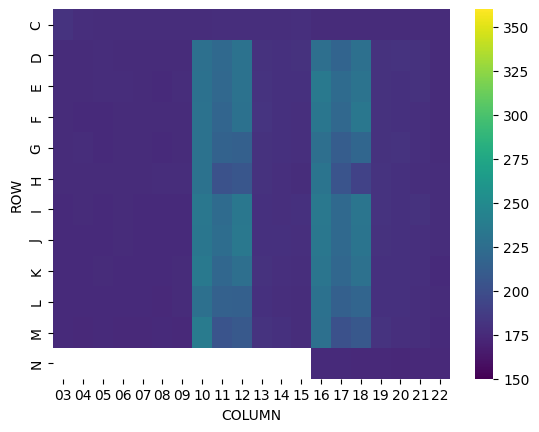

In [17]:
IntensitiesByWell_Experiment1['ROW'] = [v[:1] for v in IntensitiesByWell_Experiment1['WELL'].tolist()]
IntensitiesByWell_Experiment1['COLUMN'] = [v[1:] for v in IntensitiesByWell_Experiment1['WELL'].tolist()]

heat = IntensitiesByWell_Experiment1.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_Intensity')
sns.heatmap(heat, cmap = 'viridis',
           vmin = 150,
           vmax = 360)

<Axes: xlabel='COLUMN', ylabel='ROW'>

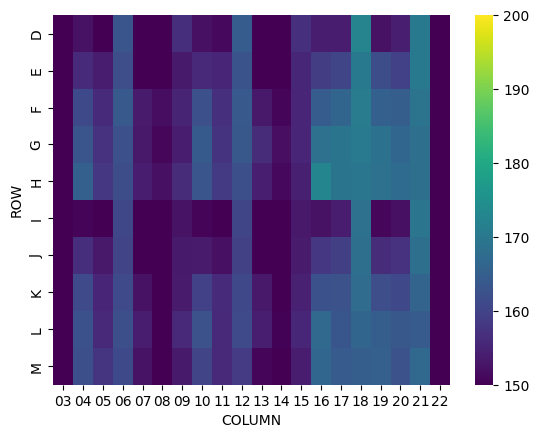

In [18]:
heat = IntensitiesByWell_Experiment2.pivot(index = 'ROW', columns = 'COLUMN', values = 'RFP_Intensity')
sns.heatmap(heat, cmap = 'viridis',
           vmin = 150,
           vmax = 200)

<Axes: xlabel='COLUMN', ylabel='ROW'>

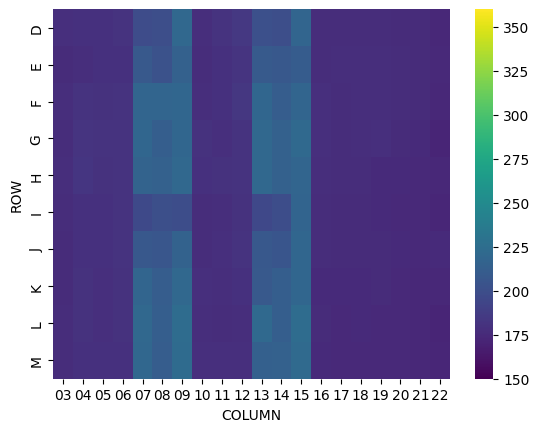

In [19]:
heat = IntensitiesByWell_Experiment2.pivot(index = 'ROW', columns = 'COLUMN', values = 'GFP_Intensity')
sns.heatmap(heat, cmap = 'viridis',
           vmin = 150,
           vmax = 360)

## subtract zero values within each day

In [20]:
IntensitiesByWell_Experiment1.CELL.unique().tolist()

['HCT116 OsTIRF74G',
 'HCT116 mChPOLR2A Clone 2',
 'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1']

In [21]:
GFPZero_1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
GFPZero_2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

RFPZero_1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()
RFPZero_2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').RFP_Intensity.mean()

In [22]:
GFPZero_1, GFPZero_2, RFPZero_1, RFPZero_2

(175.97170773601806, 174.91892281720507, 134.1345588876564, 132.27419303827685)

In [23]:
IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - GFPZero_1
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - GFPZero_2

IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['RFP_Intensity'] - RFPZero_1
IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['RFP_Intensity'] - RFPZero_2

## normalise to biallelic mCherryPOLR2A and plot over days

In [24]:
RFP_Hundred_1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Vehicle"')['RFP_Intensity_BGS'].mean()
RFP_Hundred_2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Vehicle"')['RFP_Intensity_BGS'].mean()

In [25]:
IntensitiesByWell_Experiment1.CELL.unique()

array(['HCT116 OsTIRF74G', 'HCT116 mChPOLR2A Clone 2',
       'HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1'], dtype=object)

In [26]:
HalfRFP_Hundred_1 = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 == "Vehicle" & DRUG_2 == "Vehicle"')['RFP_Intensity_BGS'].mean()
HalfRFP_Hundred_2 = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_1 == "Vehicle" & DRUG_2 == "Vehicle"')['RFP_Intensity_BGS'].mean()

In [27]:
IntensitiesByWell_Experiment1['RFP_Intensity_Fraction'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / RFP_Hundred_1
IntensitiesByWell_Experiment2['RFP_Intensity_Fraction'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / RFP_Hundred_2

In [28]:
IntensitiesByWell_Experiment1['RFP_Intensity_Fraction2'] = IntensitiesByWell_Experiment1['RFP_Intensity_BGS'] / RFP_Hundred_1
IntensitiesByWell_Experiment2['RFP_Intensity_Fraction2'] = IntensitiesByWell_Experiment2['RFP_Intensity_BGS'] / RFP_Hundred_2

In [29]:
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('DRUG_2 != "No addition"')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('DRUG_2 != "No addition"')

In [30]:
IntensitiesByWell_Combined = pd.concat([IntensitiesByWell_Experiment1,IntensitiesByWell_Experiment2])

In [31]:
IntensitiesByWell_Combined['DRUG_TIME_MINUTES_2'] = IntensitiesByWell_Combined['DRUG_TIME_MINUTES_2'].astype(int)

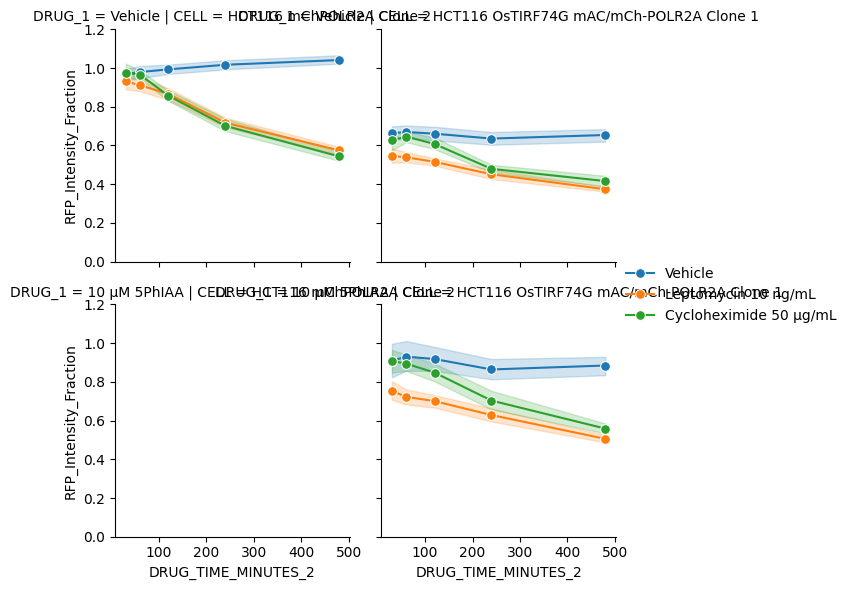

In [32]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'CELL',
                  row = 'DRUG_1',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'RFP_Intensity_Fraction',
                hue = 'DRUG_2',
                marker = 'o', markersize = 7)

g.add_legend()

In [33]:
def vehzero(d2,t):
    if d2 == "Vehicle":
        timein = 0
    elif d2 != "Vehicle":
        timein = t
    return timein

In [34]:
IntensitiesByWell_Combined['DRUG_2_TIME_IN'] = IntensitiesByWell_Combined.apply(lambda x: vehzero(x.DRUG_2, x.DRUG_TIME_MINUTES_2), axis = 1)

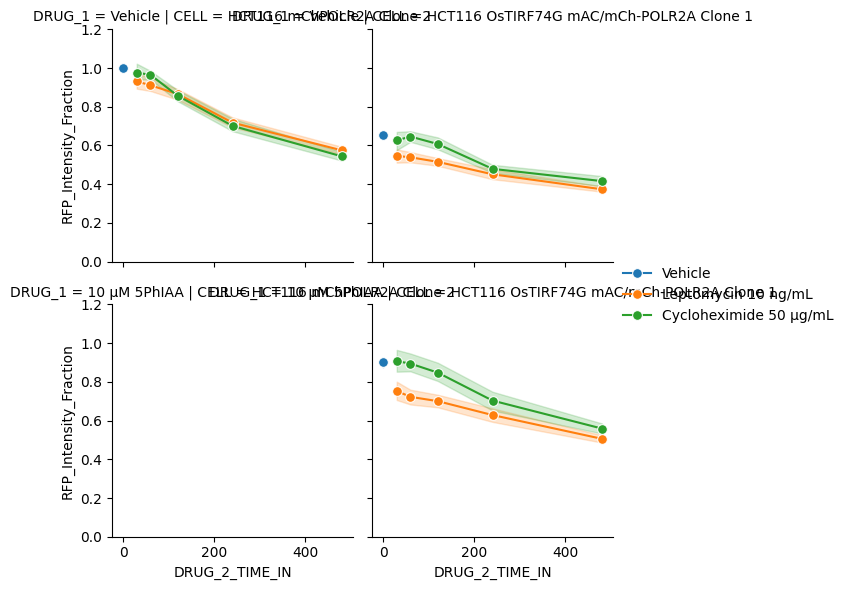

In [35]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'CELL',
                  row = 'DRUG_1',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_2_TIME_IN',
                y = 'RFP_Intensity_Fraction',
                hue = 'DRUG_2',
                marker = 'o', markersize = 7)

g.add_legend()

## normalise each condition to baseline condition, i.e. DRUG_2 == vehicle, to examine decays

In [36]:
NORM_VALUES = IntensitiesByWell_Combined.query(
    'DRUG_2 == "Vehicle"').drop(
    ['DRUG_TIME_MINUTES_1','DRUG_TIME_MINUTES_2','ROW','COLUMN','WELL'],axis = 1).groupby(
    ['EXPERIMENT','CELL', 'DRUG_1'])['RFP_Intensity_BGS'].mean().reset_index()

In [37]:
NORM_VALUES

,EXPERIMENT,CELL,DRUG_1,RFP_Intensity_BGS
0,250512_mACmChPOLR2A_Inhibitors_Chase,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,10 µM 5PhIAA,42.260488
1,250512_mACmChPOLR2A_Inhibitors_Chase,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,29.832654
2,250512_mACmChPOLR2A_Inhibitors_Chase,HCT116 mChPOLR2A Clone 2,Vehicle,42.810367
3,250520_mACmChPOLR2A_Inhibitors_Chase,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,10 µM 5PhIAA,29.453086
4,250520_mACmChPOLR2A_Inhibitors_Chase,HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1,Vehicle,22.271839
5,250520_mACmChPOLR2A_Inhibitors_Chase,HCT116 mChPOLR2A Clone 2,Vehicle,36.133853


In [38]:
def norm(e,c,d1,i):
    nv = NORM_VALUES[ (NORM_VALUES['EXPERIMENT'] == e) & (NORM_VALUES['CELL'] == c) & (NORM_VALUES['DRUG_1'] == d1) ]['RFP_Intensity_BGS'].values[0]
    return(i/nv)

In [39]:
IntensitiesByWell_Combined['RFP_Intensity_Decay'] = IntensitiesByWell_Combined.apply(lambda x: norm(x.EXPERIMENT, x.CELL, x.DRUG_1, x.RFP_Intensity_BGS), axis=1)

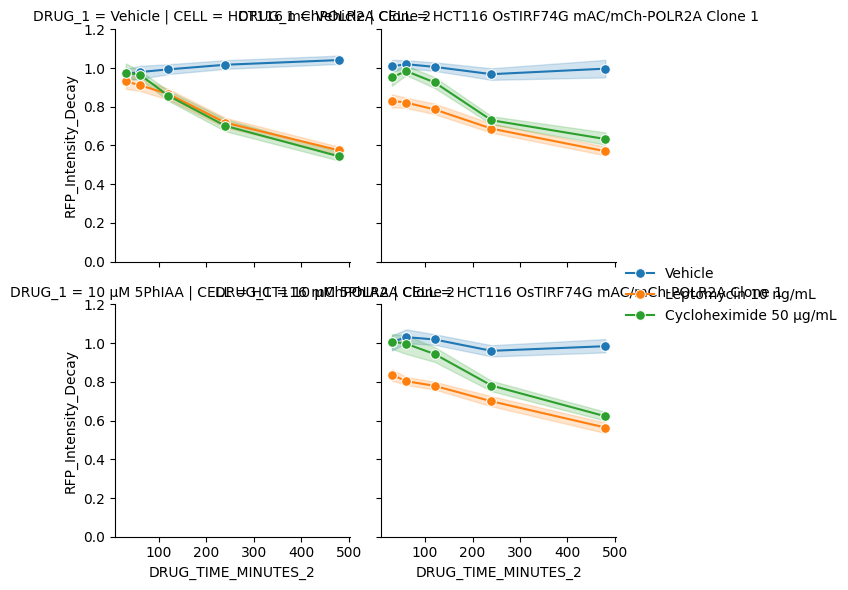

In [40]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'CELL',
                  row = 'DRUG_1',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'RFP_Intensity_Decay',
                hue = 'DRUG_2',
                marker = 'o', markersize = 7)

g.add_legend()

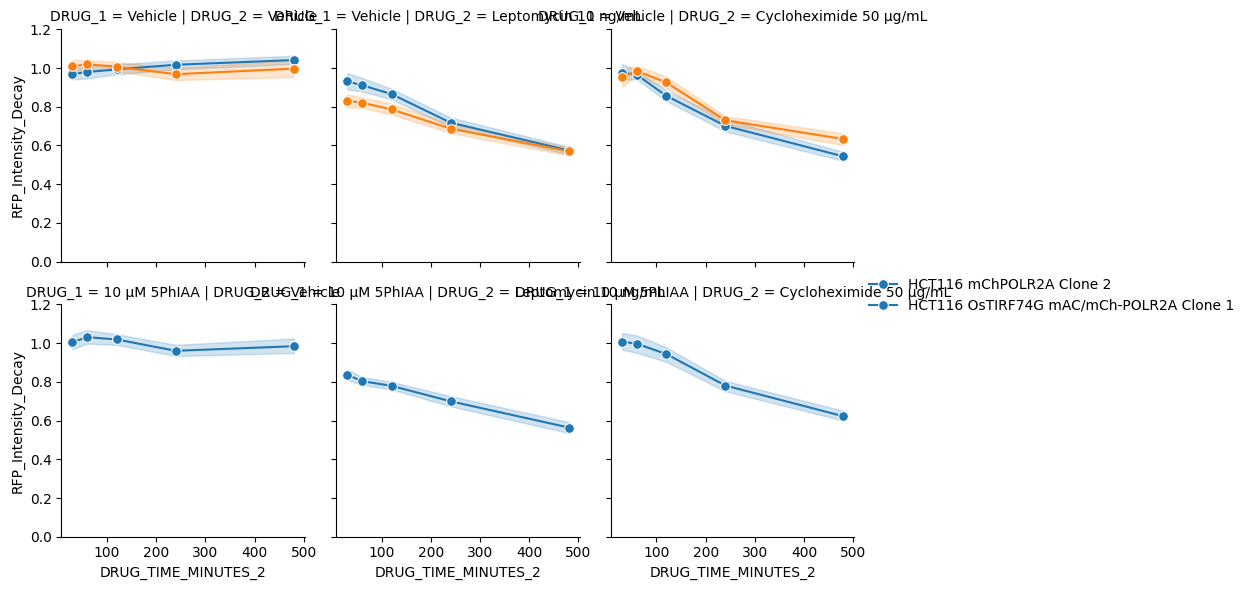

In [41]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'DRUG_2',
                  row = 'DRUG_1',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'RFP_Intensity_Decay',
                hue = 'CELL',
                marker = 'o', markersize = 7)

g.add_legend()

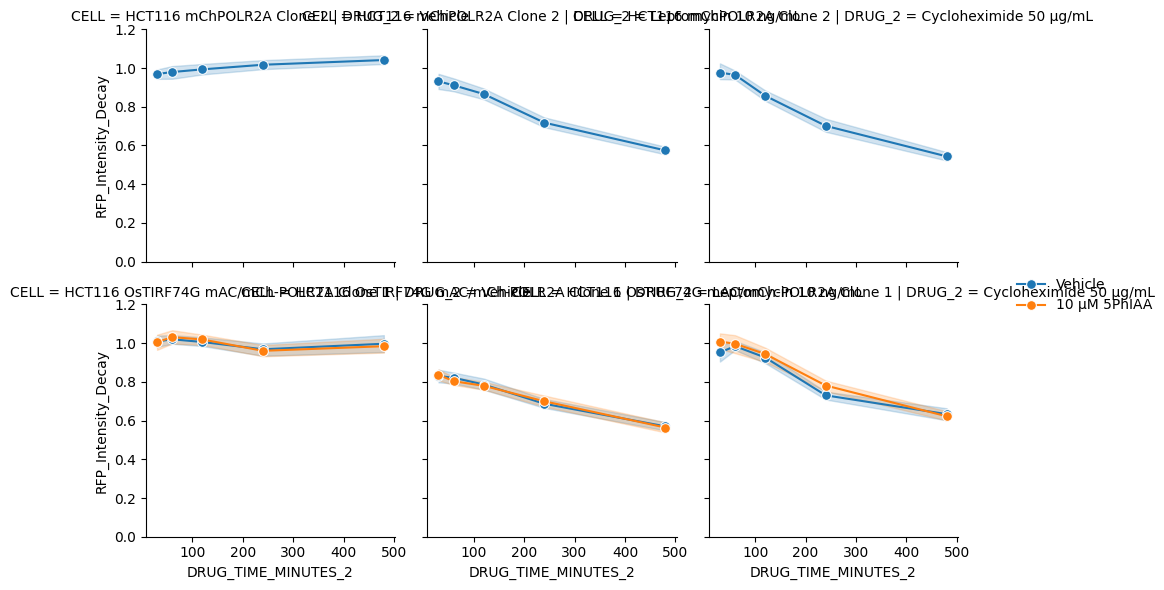

In [42]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'DRUG_2',
                  row = 'CELL',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'RFP_Intensity_Decay',
                hue = 'DRUG_1',
                marker = 'o', markersize = 7)

g.add_legend()

In [43]:
IntensitiesByWell_Combined['Log_RFP_Intensity_Decay'] = np.log(IntensitiesByWell_Combined['RFP_Intensity_Decay'])

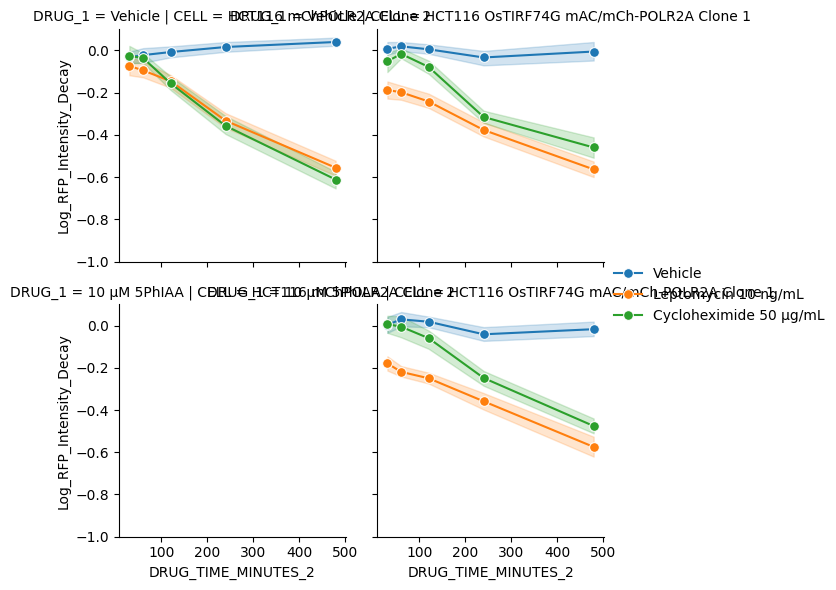

In [44]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'CELL',
                  row = 'DRUG_1',
                  ylim = (-1,0.1))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'Log_RFP_Intensity_Decay',
                hue = 'DRUG_2',
                marker = 'o', markersize = 7)

g.add_legend()

In [45]:
IntensitiesByWell_Combined.columns

Index(['WELL', 'RFP_Intensity', 'GFP_Intensity', 'DAPI_Intensity',
       'NucleusArea', 'CELL', 'DRUG_1', 'DRUG_TIME_MINUTES_1', 'DRUG_2',
       'DRUG_TIME_MINUTES_2', 'EXPERIMENT', 'ROW', 'COLUMN',
       'GFP_Intensity_BGS', 'RFP_Intensity_BGS', 'RFP_Intensity_Fraction',
       'RFP_Intensity_Fraction2', 'DRUG_2_TIME_IN', 'RFP_Intensity_Decay',
       'Log_RFP_Intensity_Decay'],
      dtype='object')

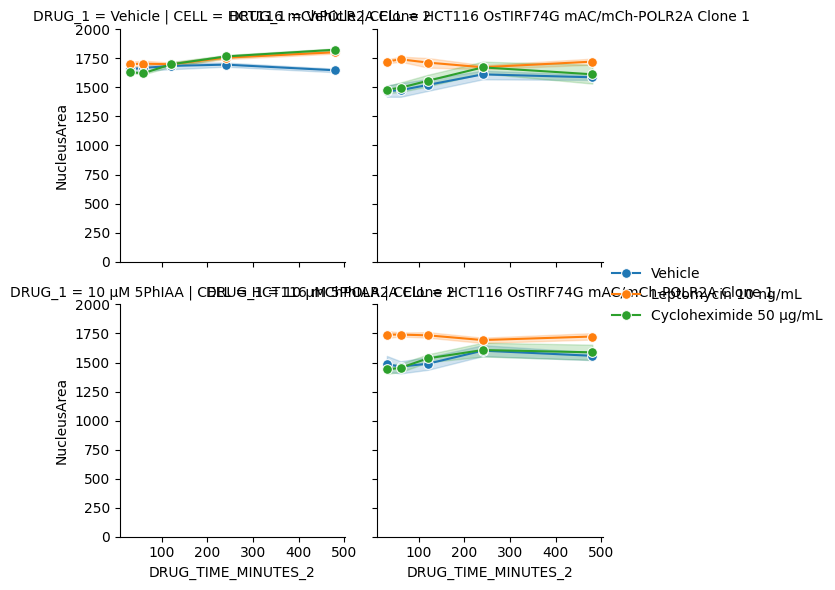

In [46]:
g = sns.FacetGrid(IntensitiesByWell_Combined,
                  col = 'CELL',
                  row = 'DRUG_1',
                 ylim = (0,2000))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_TIME_MINUTES_2',
                y = 'NucleusArea',
                hue = 'DRUG_2',
                marker = 'o', markersize = 7)

g.add_legend()

In [47]:
Decays = IntensitiesByWell_Combined.query('DRUG_2 != "Vehicle"')
Decays['TIME_MINUTES'] = Decays['DRUG_TIME_MINUTES_2'].astype(int)
Decays = Decays.query('TIME_MINUTES > 30')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_22074/3491743310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Decays['TIME_MINUTES'] = Decays['DRUG_TIME_MINUTES_2'].astype(int)


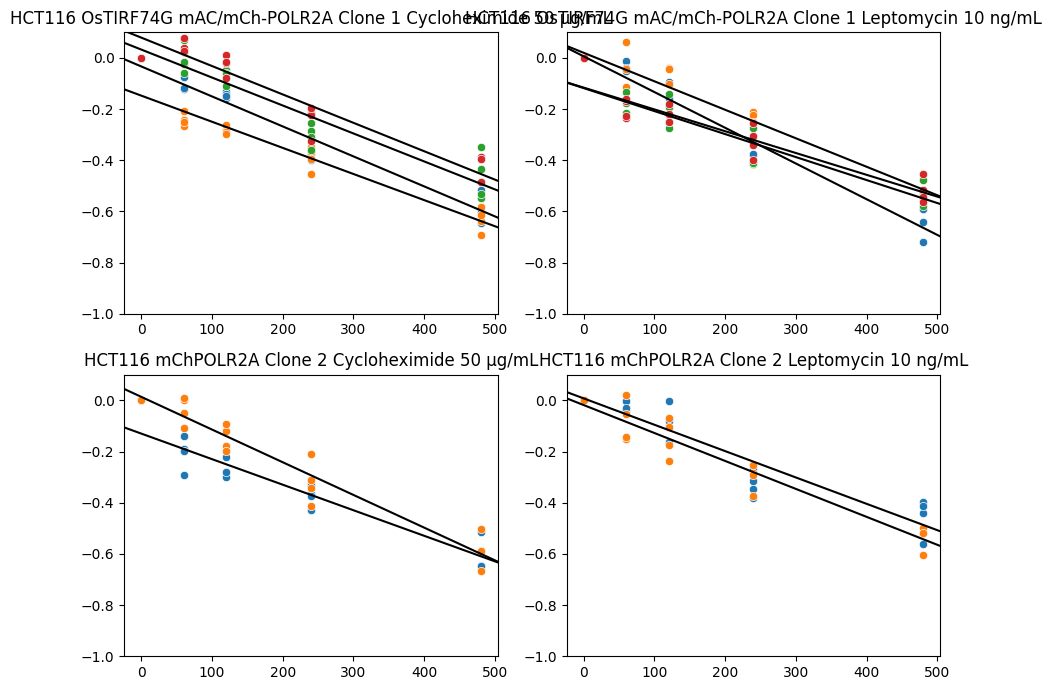

In [48]:
f, a = plt.subplots(ncols = 2, nrows = 2, figsize = (9,7))

ls = []

for i1, e in enumerate(Decays.EXPERIMENT.unique()):

    f1 = Decays[Decays['EXPERIMENT'] == e]

    for i2,d1 in enumerate(Decays.DRUG_1.unique()):
        
        f2 = f1[f1['DRUG_1'] == d1]
        
        for i3,d2 in enumerate(f1.DRUG_2.unique()):
    
            f3 = f2[f2['DRUG_2'] == d2]
        
            for i4,c in enumerate(f2.CELL.unique()):
    
                f4 = f3[f3['CELL'] == c]
    
                x_vals = f4.TIME_MINUTES.tolist()
                y_vals = f4.Log_RFP_Intensity_Decay.tolist()

                x_vals = np.insert(x_vals,0,0)
                y_vals = np.insert(y_vals,0,0)
                
                l = scipy.stats.linregress(x = x_vals, y = y_vals)
                keys = ["EXPERIMENT", "DRUG_1", "DRUG_2", "CELL", "slope", "intercept", "rvalue", "pvalue", "stderr", "intercept_stderr"]
                vals = [[e], [d1], [d2], [c], [l.slope], [l.intercept], [l.rvalue], [l.pvalue], [l.stderr], [l.intercept_stderr]]
    
                f = pd.DataFrame( dict(zip(keys,vals)) )
                ls.append(f)
    
                a[i4,i3].axline( (0, l.intercept) , slope=l.slope, color='black')
    
                sns.scatterplot(x = x_vals,
                                y = y_vals,
                                ax = a[i4,i3])
    
                a[i4,i3].set_title(str(c) + " " + str(d2))
                a[i4,i3].set_ylim(-1,0.1)

RegressionResults = pd.concat(ls)

plt.tight_layout()

In [49]:
Decays_CHX = Decays.query('DRUG_2 == "Cycloheximide 50 µg/mL"')

In [50]:
Decays_CHX.EXPERIMENT.unique()

array(['250512_mACmChPOLR2A_Inhibitors_Chase',
       '250520_mACmChPOLR2A_Inhibitors_Chase'], dtype=object)

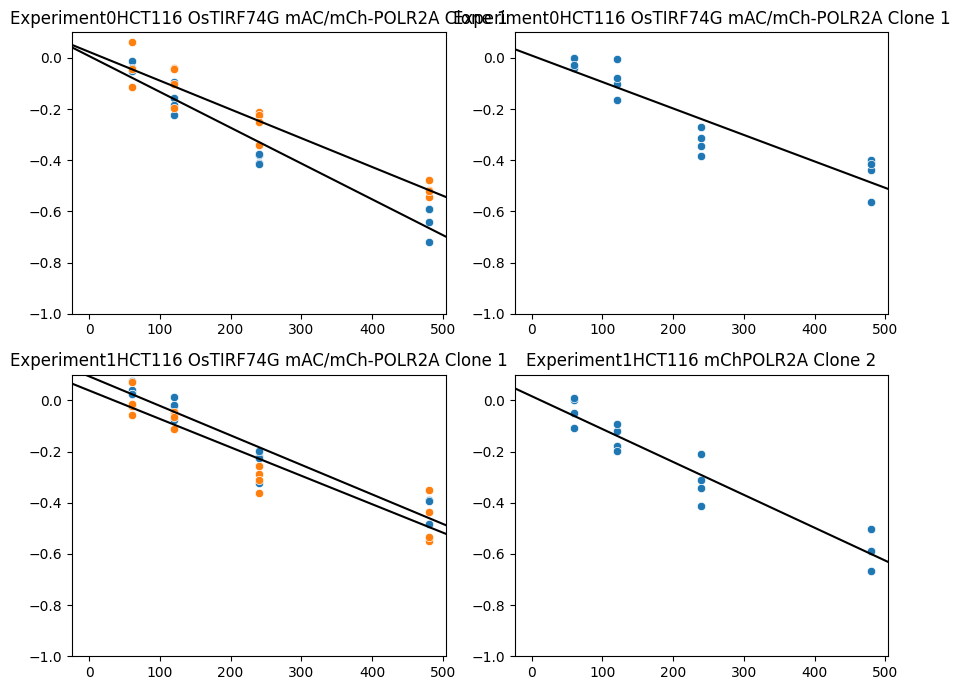

In [51]:
f, a = plt.subplots(ncols = 2, nrows = 2, figsize = (9,7))

ls = []

for i1, e in enumerate(Decays_CHX.EXPERIMENT.unique()):

    f1 = Decays_CHX[Decays_CHX['EXPERIMENT'] == e]

    for i2,d1 in enumerate(f1.DRUG_1.unique()):
        
        f2 = f1[f1['DRUG_1'] == d1]
        
        for i3,c in enumerate(f2.CELL.unique()):
    
            d2 = "CHX"
            
            f3 = f2[f2['CELL'] == c]

            x_vals = f3.TIME_MINUTES.tolist()
            y_vals = f3.Log_RFP_Intensity_Decay.tolist()
            
            l = scipy.stats.linregress(x = x_vals, y = y_vals)

            f = pd.DataFrame( dict(zip(keys,vals)) )
            ls.append(f)

            a[i1,i3].axline( (0, l.intercept) , slope=l.slope, color='black')

            sns.scatterplot(x = x_vals,
                            y = y_vals,
                            ax = a[i1,i3])

            a[i1,i3].set_title("Experiment" + str(i1) + str(c))
            a[i1,i3].set_ylim(-1,0.1)

plt.tight_layout()

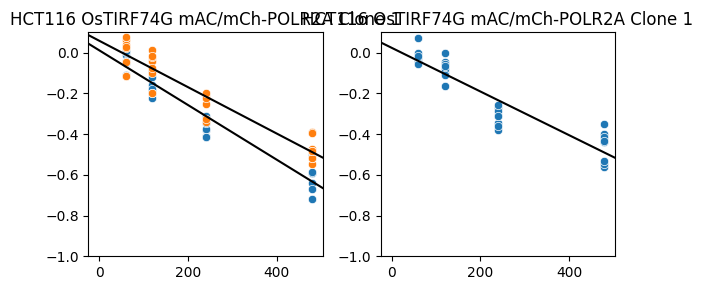

In [52]:
f, a = plt.subplots(ncols = 2, nrows = 1, figsize = (6,3))

Decays_CHX = Decays.query('DRUG_2 == "Cycloheximide 50 µg/mL"')

ls = []

for i2,d1 in enumerate(Decays_CHX.DRUG_1.unique()):
    
    f2 = Decays_CHX[Decays_CHX['DRUG_1'] == d1]
    
    for i3,c in enumerate(f2.CELL.unique()):

        d2 = "CHX"
        
        f3 = f2[f2['CELL'] == c]

        x_vals = f3.TIME_MINUTES.tolist()
        y_vals = f3.Log_RFP_Intensity_Decay.tolist()
        
        l = scipy.stats.linregress(x = x_vals, y = y_vals)

        f = pd.DataFrame( dict(zip(keys,vals)) )
        ls.append(f)

        a[i3].axline( (0, l.intercept) , slope=l.slope, color='black')

        sns.scatterplot(x = x_vals,
                        y = y_vals,
                        ax = a[i3])

        a[i3].set_title(str(c))
        a[i3].set_ylim(-1,0.1)

plt.tight_layout()

In [53]:
RegressionResults['rate_per_hour'] = RegressionResults['slope']*-1*60
RegressionResults['half_life_hours'] = [np.log(2) / r for r in RegressionResults['rate_per_hour']]

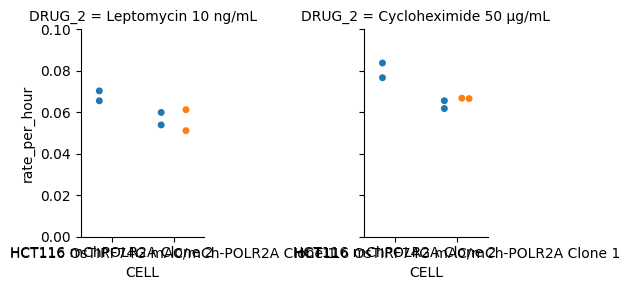

In [54]:
r = sns.FacetGrid(RegressionResults,
                  col = 'DRUG_2',
                 ylim = (0,0.1))

r.map_dataframe(sns.swarmplot,
                x = 'CELL',
                y = 'rate_per_hour',
                hue = 'DRUG_1',
                dodge = True,
                palette = 'tab10')

## make some plots for a talk

In [55]:
IntensitiesByWell_Combined['TIME_HR'] = IntensitiesByWell_Combined['DRUG_TIME_MINUTES_2']/60

In [56]:
IntensitiesByWell_Combined['DRUG_2_TIME_HOURS'] = IntensitiesByWell_Combined['DRUG_2_TIME_IN'] / 60

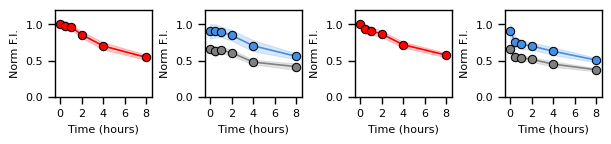

In [57]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (6,1.5), layout = 'constrained')

frm = IntensitiesByWell_Combined.query('DRUG_2 != "Leptomycin 10 ng/mL"')

sns.lineplot(frm.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
             color = 'red',
             errorbar = 'sd',
             ax = a[0],
             marker = 'o', markersize = 6, markeredgecolor = 'black')

sns.lineplot(frm.query('CELL != "HCT116 mChPOLR2A Clone 2" & DRUG_1 == "Vehicle"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
             color = 'grey',
             errorbar = 'sd',
             ax = a[1],
             marker = 'o', markersize = 6, markeredgecolor = 'black')

sns.lineplot(frm.query('CELL != "HCT116 mChPOLR2A Clone 2" & DRUG_1 != "Vehicle"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
             color = 'xkcd:dark sky blue',
                 errorbar = 'sd',
             ax = a[1],
             marker = 'o', markersize = 6, markeredgecolor = 'black')

frm2 = IntensitiesByWell_Combined.query('DRUG_2 != "Cycloheximide 50 µg/mL"')

sns.lineplot(frm2.query('CELL == "HCT116 mChPOLR2A Clone 2"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
             color = 'red',
             errorbar = 'sd',
             ax = a[2],
             marker = 'o', markersize = 6, markeredgecolor = 'black')

sns.lineplot(frm2.query('CELL != "HCT116 mChPOLR2A Clone 2" & DRUG_1 == "Vehicle"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
             color = 'grey',
             errorbar = 'sd',
             ax = a[3],
             marker = 'o', markersize = 6, markeredgecolor = 'black')

sns.lineplot(frm2.query('CELL != "HCT116 mChPOLR2A Clone 2" & DRUG_1 != "Vehicle"'),
             x = 'DRUG_2_TIME_HOURS',
             y = 'RFP_Intensity_Fraction',
                 color = 'xkcd:dark sky blue',
                 errorbar = 'sd',
             ax = a[3],
             marker = 'o', markersize = 6, markeredgecolor = 'black')


for i in range(4):
    a[i].set_box_aspect(0.9)
    a[i].set_ylim(0,1.2)
    a[i].set_yticks([0,0.5,1])
    a[i].set_xlim(-0.5,8.5)
    a[i].set_xticks(np.linspace(0,8,5))
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].set_ylabel('Norm F.I.', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.savefig('chx_lptB_chase_timecourse.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_22074/2475016274.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_22074/2475016274.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


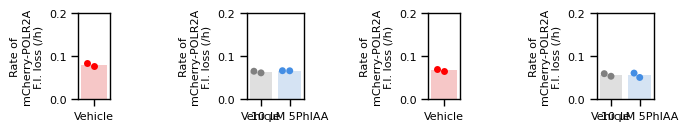

In [58]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 4, figsize = (7,1.2), layout = 'constrained')

g = sns.barplot(RegressionResults.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Cycloheximide 50 µg/mL"'),
            x = 'DRUG_1',
            y = 'rate_per_hour',
            color = 'red',
            dodge = True,
            ax = a[0],
            errorbar = None,
            alpha = 0.25)
sns.swarmplot(RegressionResults.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Cycloheximide 50 µg/mL"'),
            x = 'DRUG_1',
            y = 'rate_per_hour',
            color = 'red',
              legend = False,
            ax = a[0])

pal = sns.color_palette(['grey', 'xkcd:dark sky blue'])

g = sns.barplot(RegressionResults.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_2 == "Cycloheximide 50 µg/mL"'),
            x = 'DRUG_1', hue = 'DRUG_1', dodge = False, palette = pal,
            y = 'rate_per_hour',
            ax = a[1],
            errorbar = None,
            alpha = 0.25)
g.legend().remove()
sns.swarmplot(RegressionResults.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_2 == "Cycloheximide 50 µg/mL"'),
            x = 'DRUG_1', hue = 'DRUG_1', dodge = False, palette = pal,
            y = 'rate_per_hour',
            ax = a[1],
              legend = False)

g = sns.barplot(RegressionResults.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Leptomycin 10 ng/mL"'),
            x = 'DRUG_1',
            y = 'rate_per_hour',
            color = 'red',
            dodge = True,
            ax = a[2],
            errorbar = None,
            alpha = 0.25)
sns.swarmplot(RegressionResults.query('CELL == "HCT116 mChPOLR2A Clone 2" & DRUG_2 == "Leptomycin 10 ng/mL"'),
            x = 'DRUG_1',
            y = 'rate_per_hour',
            color = 'red',
              legend = False,
            ax = a[2])


g = sns.barplot(RegressionResults.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_2 == "Leptomycin 10 ng/mL"'),
            x = 'DRUG_1', hue = 'DRUG_1', dodge = False, palette = pal,
            y = 'rate_per_hour',
            ax = a[3],
            errorbar = None,
            alpha = 0.25)
g.legend().remove()
sns.swarmplot(RegressionResults.query('CELL == "HCT116 OsTIRF74G mAC/mCh-POLR2A Clone 1" & DRUG_2 == "Leptomycin 10 ng/mL"'),
            x = 'DRUG_1', hue = 'DRUG_1', dodge = False, palette = pal,
            y = 'rate_per_hour',
            ax = a[3],
              legend = False)

a[0].set_box_aspect(2.7)
a[1].set_box_aspect(1.5)

a[2].set_box_aspect(2.7)
a[3].set_box_aspect(1.5)

for i in range(4):
    a[i].set_ylabel('Rate of\nmCherry-POLR2A\nF.I. loss (/h)', fontsize = 8)
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylim(0,0.2)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.savefig('chx_lpt_chase_fitting_results.svg')

In [62]:
IntensitiesByWell_Combined.to_csv('mACmChPOLR2A_Inhibitors_Chase_normalised_data.csv')